In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
E_BULK = -16.87567675

correspondences = {1:{0:(1, 1),
                      1:(1, 0)},
                  11:{0:(11, 1),
                      1:(11, 0),
                      2:(11, 3),
                      3:(11, 2),
                      4:(11, 4)},
                  111:{0:(111, 1),
                       1:(111, 0),
                       2:(111, 3),
                       3:(111, 2)}
                  }

def surface_energy(Eb, Eslab, N, A):
    return 16.0217733*(Eslab - (N)*Eb)/(4*A)

def surf_energ_from_df_row(df_row, column_name):
    Eb = E_BULK
    Eslab = df_row[column_name]
    N = -1
    for i in str(df_row['Slab_size']):
        N += int(i)
    A = df_row['Slab_area']
    
    if ((df_row['Term'] == 0) or (df_row['Term'] == 1)):
        N_eff = 2*N+1
        
    elif (df_row['Facet'] == 11) and ((df_row['Term'] != 0) and (df_row['Term'] != 1)):
        N_eff = 2*N
    
    elif (df_row['Facet'] == 111) and ((df_row['Term'] != 0) and (df_row['Term'] != 1)):
        N_eff = 2*N-1
    
    return N, surface_energy(Eb, Eslab, N_eff, A)

def df_surf_creating(df, column_name='Termination Energy'):
    dic = {}
    for facet in correspondences.keys():
        for term in correspondences[facet].keys():
            df_facet = df.loc[(df["Facet"]==facet) & (df["Term"]==term)]
            N = []
            SURF_ENERG = []
            for i_n in range(len(df_facet)):
                n, surf_energ = surf_energ_from_df_row(df_facet.iloc[i_n], column_name)  # Access row by integer position
                N.append(n), SURF_ENERG.append(surf_energ)
            
            terminat = str(facet)+'-'+str(term)
            dic[terminat] = SURF_ENERG
    dic['n'] = N
    return pd.DataFrame(dic)
    

In [3]:
# Example: Reading a space-delimited text file
df_surf = pd.read_csv('../../inputs/energies/energies_sym.txt', sep=' ', header=0)
df_surf

,Facet,Term,Slab_size,Total_conv,Struc_conv,Elec_conv,Total_energ,Energ_unit,Froz_energ,Slab_area,Unnamed: 10
0,1,0,101,True,True,True,-26.592251,eV,-26.472940,34.320156,NaN
1,1,0,102,True,True,True,-43.556744,eV,-43.374631,34.320156,NaN
2,1,0,202,True,True,True,-60.453880,eV,-60.249589,34.320156,NaN
3,1,0,212,True,True,True,-77.334345,eV,-77.121740,34.320156,NaN
4,1,0,222,True,True,True,-94.208397,eV,-93.993918,34.320156,NaN
...,...,...,...,...,...,...,...,...,...,...,...
94,111,3,222,True,True,True,-67.870832,eV,-64.968805,59.444254,NaN
95,111,3,232,True,True,True,-84.738097,eV,-81.844441,59.444254,NaN
96,111,3,242,True,True,True,-101.608263,eV,-98.716534,59.444254,NaN
97,111,3,252,True,True,True,-118.472479,eV,-115.590684,59.444254,NaN


In [4]:
1/(16.0217733/(2 *  59.444254))

7.420433791807553

In [5]:
df_surf["Cleavage Energy"] = None

In [6]:
for i in correspondences.keys():
    for j in correspondences[i].keys():
        l, m = correspondences[i][j]
        df_surf.loc[(df_surf["Facet"] == i) & (df_surf["Term"] == j), "Cleavage Energy"] = np.array(df_surf.loc[(df_surf["Facet"] == i) & (df_surf["Term"] == j)]["Froz_energ"]) + (np.array(df_surf.loc[(df_surf["Facet"] == l) & (df_surf["Term"] == m)]["Froz_energ"]))
        df_surf.loc[(df_surf["Facet"] == i) & (df_surf["Term"] == j), "Relaxed Energy"] = np.array(df_surf.loc[(df_surf["Facet"] == i) & (df_surf["Term"] == j)]["Total_energ"]) + (np.array(df_surf.loc[(df_surf["Facet"] == l) & (df_surf["Term"] == m)]["Total_energ"]))
        
df_surf["Termination Energy"] = df_surf["Cleavage Energy"] + 2*((df_surf["Total_energ"]) - np.array(df_surf["Froz_energ"]))

In [7]:
df_surf

,Facet,Term,Slab_size,Total_conv,Struc_conv,Elec_conv,Total_energ,Energ_unit,Froz_energ,Slab_area,Unnamed: 10,Cleavage Energy,Relaxed Energy,Termination Energy
0,1,0,101,True,True,True,-26.592251,eV,-26.472940,34.320156,NaN,-49.070723,-49.440139,-49.309344
1,1,0,102,True,True,True,-43.556744,eV,-43.374631,34.320156,NaN,-82.855351,-83.381461,-83.219576
2,1,0,202,True,True,True,-60.453880,eV,-60.249589,34.320156,NaN,-116.603072,-117.179892,-117.011654
3,1,0,212,True,True,True,-77.334345,eV,-77.121740,34.320156,NaN,-150.34707,-150.942126,-150.772279
4,1,0,222,True,True,True,-94.208397,eV,-93.993918,34.320156,NaN,-184.091407,-184.687335,-184.520366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,111,3,222,True,True,True,-67.870832,eV,-64.968805,59.444254,NaN,-143.73688,-147.652661,-149.540933
95,111,3,232,True,True,True,-84.738097,eV,-81.844441,59.444254,NaN,-177.478617,-181.393531,-183.26593
96,111,3,242,True,True,True,-101.608263,eV,-98.716534,59.444254,NaN,-211.215252,-215.128719,-216.998709
97,111,3,252,True,True,True,-118.472479,eV,-115.590684,59.444254,NaN,-244.95373,-248.857485,-250.717321


In [8]:
df_surf_new = df_surf_creating(df_surf)

In [9]:
df_surf_new

,1-0,1-1,11-0,11-1,11-2,11-3,11-4,111-0,111-1,111-2,111-3,n
0,0.153785,0.123255,0.610257,0.519016,NaN,NaN,NaN,0.540898,0.430695,NaN,NaN,1
1,0.135242,0.097456,0.620673,0.514579,0.285659,0.136913,0.161372,0.495099,0.451398,NaN,NaN,2
2,0.130489,0.091220,0.590378,0.547966,0.269592,0.103019,0.107463,0.496870,0.464243,0.430000,0.138837,3
3,0.129407,0.089762,0.553357,0.581748,0.267431,0.096101,0.107914,0.502464,0.473701,0.416333,0.152511,4
4,0.129789,0.090815,0.553526,0.583496,0.267380,0.096175,0.107370,0.507190,0.480220,0.412153,0.157683,5
5,0.130608,0.091091,0.553014,0.585408,0.268510,0.097376,0.108524,0.512647,0.482037,0.411789,0.159459,6
6,0.131238,0.091947,0.554079,0.586645,0.269738,0.098625,0.109798,0.516809,0.483629,0.412716,0.160711,7
7,0.131757,0.092640,0.555370,0.587561,0.270919,0.099849,0.110983,0.519925,0.485434,0.413554,0.162917,8
8,0.132590,0.093455,0.556740,0.588937,0.272104,0.101046,0.112159,0.522226,0.486880,0.416324,0.164063,9


In [10]:
colors = ["#8D6A9F", "#A99BB9", "gray", "#C5CBD3", "#A9C4C6", "#8CBCB9", "#B5B081", "#C9AA65", "#DDA448", "#CC6C3C", "#BB342F"]

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

N = 11
colors = plt.cm.tab20(np.linspace(0, 1, N))
colors[0], colors[5], colors[10], colors[2], colors[3], colors[1], colors[7] = colors[2].copy(), colors[3].copy(), colors[0].copy(), colors[5].copy(), colors[10].copy(), colors[7].copy(), colors[1].copy()
colors[6], colors[7] = colors[7].copy(), colors[6].copy()
colors[6], colors[1] = colors[1].copy(), colors[6].copy()
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

In [12]:
colors

array([[0.17254902, 0.62745098, 0.17254902, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       [0.54901961, 0.3372549 , 0.29411765, 1.        ],
       [0.61960784, 0.85490196, 0.89803922, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ],
       [0.83921569, 0.15294118, 0.15686275, 1.        ],
       [0.49803922, 0.49803922, 0.49803922, 1.        ],
       [0.89019608, 0.46666667, 0.76078431, 1.        ],
       [0.7372549 , 0.74117647, 0.13333333, 1.        ],
       [0.09019608, 0.74509804, 0.81176471, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ]])

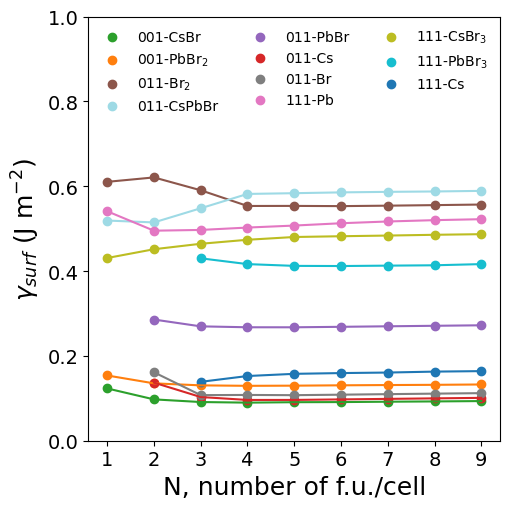

In [17]:
labels = {'1-1':r'001-CsBr',
          '1-0':r'001-PbBr$_2$',
          '11-0':r'011-Br$_2$',
          '11-1':r'011-CsPbBr',
          '11-2':r'011-PbBr',
          '11-3':r'011-Cs',
          '11-4':r'011-Br',
          '111-0':r'111-Pb',
          '111-1':r'111-CsBr$_3$',
          '111-2':r'111-PbBr$_3$',
          '111-3':r'111-Cs'
         }


fig = plt.figure(figsize=(5.2, 5.2))

for facet in labels.keys():
    plt.plot(df_surf_new['n'], df_surf_new[facet])
    plt.scatter(df_surf_new['n'], df_surf_new[facet], label = labels[facet])
plt.xlabel("N, number of f.u./cell", fontsize=18)
plt.ylabel(r"$\gamma_{surf}$ (J m$^{-2}$)", fontsize=18)
plt.legend(ncols=3, frameon=False, fontsize=10)
plt.ylim(0, 1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0.25, 8.5)
plt.grid(False)
plt.tight_layout()
plt.savefig('Surface energy convergence relat.png', dpi=600)
plt.show()

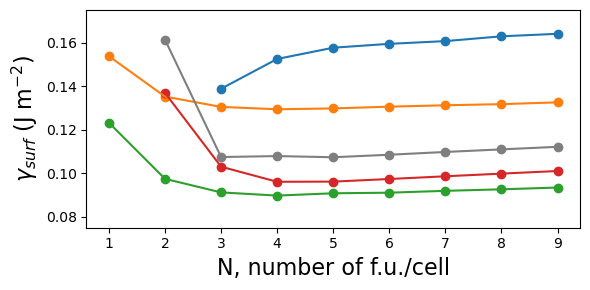

In [14]:
labels = {'1-1':r'001-CsBr',
          '1-0':r'001-PbBr$_2$',
          '11-0':r'011-Br$_2$',
          '11-1':r'011-CsPbBr',
          '11-2':r'011-PbBr',
          '11-3':r'011-Cs',
          '11-4':r'011-Br',
          '111-0':r'111-Pb',
          '111-1':r'111-CsBr$_3$',
          '111-2':r'111-PbBr$_3$',
          '111-3':r'111-Cs'
         }



fig = plt.figure(figsize=(6, 3))

for facet in labels.keys():
    plt.plot(df_surf_new['n'], df_surf_new[facet])
    plt.scatter(df_surf_new['n'], df_surf_new[facet], label = labels[facet])
plt.xlabel("N, number of f.u./cell", fontsize=16)
plt.ylabel(r"$\gamma_{surf}$ (J m$^{-2}$)", fontsize=16)
#plt.legend(ncols=3)
plt.ylim(0.075, .175)
#plt.xlim(0.25, 8.5)
plt.grid(False)
plt.tight_layout()
plt.savefig('Surface energy convergence2.png', dpi=600)
plt.show()

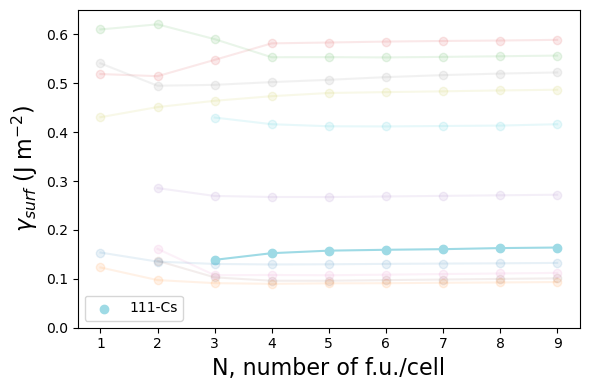

In [58]:
labels = {'1-0':'001-CsBr',
          '1-1':'001-PbBr2',
          '11-0':'011-Br2',
          '11-1':'011-CsPbBr',
          '11-2':'011-PbBr',
          '11-3':'011-Cs',
          '11-4':'011-Br',
          '111-0':'111-Pb',
          '111-1':'111-CsBr3',
          '111-2':'111-PbBr3',
          '111-3':'111-Cs'
         }


fig = plt.figure(figsize=(6, 4))

for facet in df_surf_new.drop('n', axis=1).keys():
    if facet == '111-3':
        plt.plot(df_surf_new['n'], df_surf_new[facet])
        plt.scatter(df_surf_new['n'], df_surf_new[facet], label = labels[facet])
    else:
        plt.plot(df_surf_new['n'], df_surf_new[facet], alpha=0.1)
        plt.scatter(df_surf_new['n'], df_surf_new[facet], alpha=0.1)
plt.xlabel("N, number of f.u./cell", fontsize=16)
plt.ylabel(r"$\gamma_{surf}$ (J m$^{-2}$)", fontsize=16)
plt.legend(ncols=3)
plt.ylim(0, 0.65)
#plt.xlim(0.25, 8.5)
plt.grid(False)
plt.tight_layout()
plt.savefig('Surface energy convergence3.png', dpi=600)
plt.show()

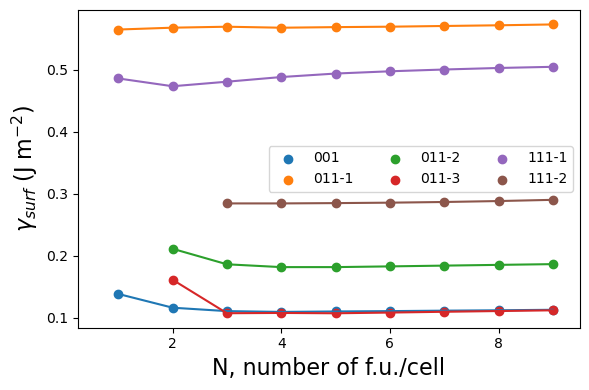

In [29]:
df_surf_R = df_surf_creating(df_surf, column_name="Relaxed Energy")

labels = {'1-0': '001',
         '11-0': '011-1',
         '11-2': '011-2',
         '11-4': '011-3',
         '111-0': '111-1',
         '111-2': '111-2'}

fig = plt.figure(figsize=(6, 4))

for facet in df_surf_R.drop('n', axis=1).keys():
    if facet in labels.keys():
        plt.plot(df_surf_R['n'], df_surf_R[facet])
        plt.scatter(df_surf_R['n'], df_surf_R[facet], label = labels[facet])
plt.xlabel("N, number of f.u./cell", fontsize=16)
plt.ylabel(r"$\gamma_{surf}$ (J m$^{-2}$)", fontsize=16)
plt.legend(ncols=3)
plt.ylim(0, .3)
plt.xlim(0.25, 9.5)
plt.grid(False)
plt.tight_layout()
#plt.savefig('Figures/E_Poly_CsPbBr3.png', dpi=600)
plt.show()

## Save

In [15]:
E_BULK = -16.87567675

def surface_energy(Eb, Eslab, N, A):
    return 16.0217733*(Eslab - (2*N+1)*Eb)/(4*A)

def surf_energ_from_df_row(df_row):
    Eb = E_BULK
    Eslab = df_row['Total_energ']
    N = -1
    for i in str(df_row['Slab_size']):
        N += int(i)
    A = df_row['Slab_area']
    
    return N, surface_energy(Eb, Eslab, N, A)

def df_surf_creating(df):
    dic = {}
    for facet in set(df['Facet'].values):
        df_facet = df.loc[df["Facet"]==facet]
        N = []
        SURF_ENERG = []
        for i_n in range(len(df_facet)):
            n, surf_energ = surf_energ_from_df_row(df_facet.iloc[i_n])  # Access row by integer position
            N.append(n), SURF_ENERG.append(surf_energ)
        
        dic[facet] = SURF_ENERG
    dic['n'] = N
    return pd.DataFrame(dic)
    